# 3. Use k-NN on the New Dataset
Now that we have our newly extracted dataset, let's use k-NN on it

## Import Required Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import neighbors

## Read Dataset from File

In [9]:
columns = ["age", "education-num", "capital-gain", "income"]
data = pd.read_csv('dataset.csv', names=columns, sep=',', skipinitialspace=True)
data

,age,education-num,capital-gain,income
0,38,9,0,<=50K
1,53,7,0,<=50K
2,49,5,0,<=50K
3,31,14,14084,>50K
4,42,13,5178,>50K
...,...,...,...,...
1815,53,15,27828,>50K
1816,37,15,15024,>50K
1817,57,9,99999,>50K
1818,38,13,15020,>50K


Use `age`, `education-num`, `capital-gain` features for input (X) and `income` feature for output/target (y)

In [3]:
X = data[['age', 'education-num', 'capital-gain']]
X = StandardScaler().fit_transform(X)
y = data['income']
y = y.to_numpy()

## Gather the Accuracy of k-NN Classification Model on Our Dataset

With parameter weights='uniform'

In [4]:
accuracies = []

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    test_accuracies = []
    for n_neighbors in range(1, 100):
        clf = neighbors.KNeighborsClassifier(n_neighbors, weights='uniform')
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        accuracy = (y_pred == y_test).mean()
        test_accuracies.append(accuracy)

    accuracies.append(test_accuracies)
    print(i, end=' ')

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 

With parameter weights='distance'

In [5]:
accuracies_dist = []

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    test_accuracies = []
    for n_neighbors in range(1, 100):
        clf = neighbors.KNeighborsClassifier(n_neighbors, weights='distance')
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        accuracy = (y_pred == y_test).mean()
        test_accuracies.append(accuracy)

    accuracies_dist.append(test_accuracies)
    print(i, end=' ')

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 

## Plot the Results

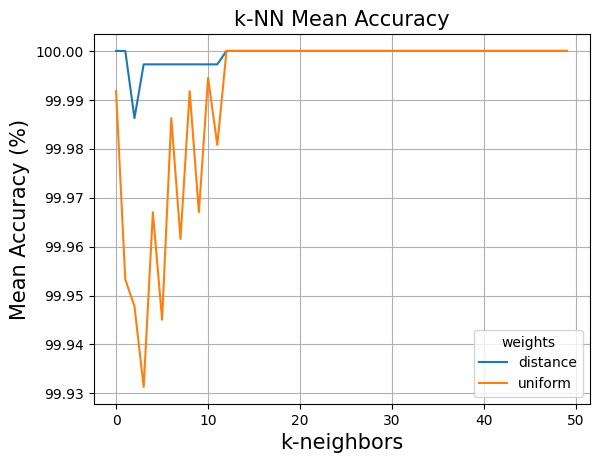

In [8]:
fig, ax = plt.subplots()

ax.plot(np.array(accuracies_dist).mean(axis=0)[:50]*100, label='distance')
ax.plot(np.array(accuracies).mean(axis=0)[:50]*100, label='uniform')

ax.grid()
ax.set_xlabel('k-neighbors', fontsize=15)
ax.set_ylabel('Mean Accuracy (%)', fontsize=15)
ax.set_title('k-NN Mean Accuracy', fontsize=15)
plt.legend(title='weights')

# plt.savefig('kNN - k-NN Mean Accuracy.png', transparent=True, bbox_inches='tight')
plt.show()